# PopOut AI — Technical Documentation
### Bitboard Engine · MCTS · Solver · Numba Optimisation · Benchmark

---

This notebook documents every component of the PopOut AI project from the ground up.  
Each section explains *why* a design decision was made, not just *what* the code does.

**Contents**
1. Bitboard Engine — memory layout, DROP, POP, win detection  
2. Standard MCTS (UCT) — the four phases, exploration vs exploitation  
3. Numba Acceleration — JIT compilation, two-tier architecture  
4. MCTS-Solver — proof propagation, AND/OR trees, minimax distance  
5. Optimised Solver — hybrid and full-JIT variants  
6. Benchmark — iterations/s, head-to-head tournament, conclusions  

In [1]:
import sys, os, time, math
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('..'))

from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import has_won, evaluate_after_move, board_signature
from src.mcts.standard.uct_standard import StandardUCT
from src.mcts.standard.uct_solver import SolverMCTS
from src.mcts.optimized.numba_mcts import NumbaMCTS, FlatNumbaMCTS, warmup
from src.mcts.optimized.numba_solver import NumbaSolverMCTS, FlatNumbaSolverMCTS
from src.interfaces.cli import run_cvc

FIGURES_DIR = os.path.join(os.path.abspath('..'), 'data', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Part 1 — Bitboard Engine

The game state must be read, written, and cloned millions of times per second during MCTS.  
A naïve 2D list representation would be too slow. Instead, we use **bitboards**.

### What is a bitboard?

A bitboard encodes an entire board state into a single integer.  
Each bit represents one cell: `1` = occupied, `0` = empty.  
Because CPUs operate on 64-bit integers natively, operations that would
require a loop over 42 cells reduce to a single instruction.

We use **two** integers — one per player:
```
mask_p1  — bit = 1 where Player 1 has a piece
mask_p2  — bit = 1 where Player 2 has a piece
```

### Memory layout

The board is 7 columns × 6 rows.  We allocate **7 bits per column** (6 rows + 1 guard bit),
so the full layout fits in 49 bits — well within a 64-bit integer.

```
Bit index = col * COL_SIZE + row    (COL_SIZE = 7)

  col 0   col 1   col 2  ...  col 6
  ──────  ──────  ──────      ──────
  bit 6   bit 13  bit 20      bit 48   ← guard bit (always 0)
  bit 5   bit 12  bit 19      bit 47   ← row 5 (top)
  bit 4   bit 11  bit 18      bit 46   ← row 4
  bit 3   bit 10  bit 17      bit 45   ← row 3
  bit 2   bit  9  bit 16      bit 44   ← row 2
  bit 1   bit  8  bit 15      bit 43   ← row 1
  bit 0   bit  7  bit 14      bit 42   ← row 0 (bottom)
```

The guard bit prevents overflow: when we detect whether a column is full
(checking bit `col*7 + 5`), bits from adjacent columns never bleed in.

In [2]:
COL_SIZE = 7
ROWS     = 6
COLS     = 7

def bit_pos(row, col):
    return col * COL_SIZE + row

def show_bitmask(mask, label=''):
    """Print a 7x6 board showing which bits are set."""
    print(f'  {label}')
    for r in range(ROWS - 1, -1, -1):
        row_str = '  '
        for c in range(COLS):
            bit = 1 << bit_pos(r, c)
            row_str += ('█ ' if mask & bit else '. ')
        print(row_str)
    print('  0 1 2 3 4 5 6')
    print(f'  integer value: {mask}  (binary: {mask:049b})')

# Empty board
board = PopOutBoard()
print('Empty board — both masks are 0:')
show_bitmask(0, 'mask_p1 = 0')

Empty board — both masks are 0:
  mask_p1 = 0
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  0 1 2 3 4 5 6
  integer value: 0  (binary: 0000000000000000000000000000000000000000000000000)


### DROP operation

Dropping a piece into column `c` means placing it on top of whatever is already there —
the lowest empty row in that column.

The trick uses a single bitwise expression:
```python
col_mask  = (merged >> (col * 7)) & 0b111111   # extract the 6 occupied bits of the column
new_piece = ((col_mask + 1) & ~col_mask)        # lowest 0-bit above the stack
```

Why does `(x + 1) & ~x` give the lowest zero bit?

```
col_mask  = 0b000111   (rows 0, 1, 2 occupied)
col_mask+1= 0b001000   (carry propagates through the trailing 1s)
~col_mask = 0b111000   (inverted)
AND       = 0b001000   → bit 3 = row 3, the first empty slot  ✓
```

Then we shift `new_piece` back to the correct absolute bit position and OR it into the player's mask.

In [3]:
# Step-by-step DROP demonstration
board = PopOutBoard()

print('=== DROP into column 3, Player 1 ===')
print('Before:')
show_bitmask(board.mask_p1, 'mask_p1')

board.apply_move(3)   # drop col 3, Player 1
print('\nAfter drop col 3 (P1):')
show_bitmask(board.mask_p1, 'mask_p1')
print(f'  bit 21 (col3, row0) set? {bool(board.mask_p1 & (1 << bit_pos(0, 3)))}')

# Drop again in same column
board.apply_move(3)   # P2 drops col 3
board.apply_move(3)   # P1 drops col 3 again
print('\nAfter two more drops in col 3 (P2 then P1):')
show_bitmask(board.mask_p1, 'mask_p1  (P1 pieces)')
show_bitmask(board.mask_p2, 'mask_p2  (P2 pieces)')

=== DROP into column 3, Player 1 ===
Before:
  mask_p1
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  0 1 2 3 4 5 6
  integer value: 0  (binary: 0000000000000000000000000000000000000000000000000)

After drop col 3 (P1):
  mask_p1
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . █ . . . 
  0 1 2 3 4 5 6
  integer value: 2097152  (binary: 0000000000000000000000000001000000000000000000000)
  bit 21 (col3, row0) set? True

After two more drops in col 3 (P2 then P1):
  mask_p1  (P1 pieces)
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . █ . . . 
  . . . . . . . 
  . . . █ . . . 
  0 1 2 3 4 5 6
  integer value: 10485760  (binary: 0000000000000000000000000101000000000000000000000)
  mask_p2  (P2 pieces)
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . █ . . . 
  . . . . . . . 
  0 1 2 3 4 5 6
  integer value: 4194304  (binary: 0000000000000000000000000010

### POP operation

Popping removes the **bottom** piece (row 0) of a column and **shifts all pieces above it down by one row**.  
This is what makes PopOut different from Connect-4: pieces can be removed, creating cycles.

```python
col_bit_mask = 0b111111 << (col * 7)           # mask for all 6 rows of this column
mask_p1 = (mask_p1 & ~col_bit_mask)            # clear the entire column
        | ((mask_p1 & col_bit_mask) >> 1)      # shift column contents down 1 bit
        & col_bit_mask                          # re-apply the column mask (CLEAN)
```

Shifting right by 1 moves every piece one row down.  
The bottom piece (row 0, bit 0) shifts out of the 6-bit window and disappears.
The CLEAN_MASK (`& col_bit_mask`) ensures no bits bleed into adjacent columns.

```
Before pop col 3:    After >> 1:     After CLEAN:
  .  .  .  X  .      .  .  .  .      .  .  .  .    ← row 5 (top)
  .  .  .  X  .      .  .  .  X      .  .  .  X    ← row 4
  .  .  .  O  .      .  .  .  X      .  .  .  X    ← row 3
  .  .  .  X  .  →   .  .  .  O  →   .  .  .  O    ← row 2
  .  .  .  O  .      .  .  .  X      .  .  .  X    ← row 1
  .  .  .  X  .      .  .  .  O      .  .  .  O    ← row 0 (bottom, was P1)
                                      ↑ P1 piece removed
```

In [4]:
# Setup: fill column 3 with alternating pieces
board = PopOutBoard()
for _ in range(6):
    board.apply_move(3)   # alternates P1, P2, P1, P2, P1, P2

print('Before POP:')
print(board)
print(f'  mask_p1 col3 bits: {(board.mask_p1 >> 21) & 0b111111 :06b}  (rows 0-5)')
print(f'  mask_p2 col3 bits: {(board.mask_p2 >> 21) & 0b111111 :06b}')

# Pop col 3 — P1 is next to move (it's their turn after 6 moves)
# But who has the bottom piece? Let's check
has_bottom_p1 = bool(board.mask_p1 & (1 << bit_pos(0, 3)))
print(f'\nP1 has bottom of col 3? {has_bottom_p1}')
print(f'Current player: {board.current_player}')

# Let current player pop col 3 (move 10 = pop col 3)
if 10 in board.legal_moves():
    board.apply_move(10)   # pop col 3
    print('\nAfter POP col 3:')
    print(board)

Before POP:
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6
  mask_p1 col3 bits: 010101  (rows 0-5)
  mask_p2 col3 bits: 101010

P1 has bottom of col 3? True
Current player: 1

After POP col 3:
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
. . . O . . .
0 1 2 3 4 5 6


### WIN detection

Checking for 4-in-a-row is the most critical operation — called after every move.  
The bitboard layout makes it a pure sequence of bitwise shifts and ANDs, with **no loops**.

The key insight: if bit `i` and bit `i+k` are both set in the player's mask,
then `mask & (mask >> k)` has bit `i` set.  
Chaining this twice with shift `2k` detects 4 consecutive positions.

```python
# Vertical (4 in same column — rows differ by 1 bit)
m = b & (b >> 1);   if m & (m >> 2): WIN

# Horizontal (4 in same row — columns differ by 7 bits = COL_SIZE)
m = b & (b >> 7);   if m & (m >> 14): WIN

# Diagonal \ (down-left to up-right — col+1 row+1 = +8 bits... wait)
# Actually: moving right one col AND up one row = +7+1 = +8? No...
# Going right (+7 bits) and down (-1 bit) = +6 bits total
m = b & (b >> 6);   if m & (m >> 12): WIN

# Diagonal / (down-right — col+1 row-1 = +7-1 = +6? No: right = +7, up = +1 = +8)
m = b & (b >> 8);   if m & (m >> 16): WIN
```

Why these specific shift values?

```
Direction          Cell offset      Bit offset
──────────────     ─────────────    ──────────
Vertical           (+1 row, 0 col)  +1
Horizontal         (0 row, +1 col)  +7  (= COL_SIZE)
Diagonal \         (+1 row, +1 col) +8  (= 7 + 1)
Diagonal /         (-1 row, +1 col) +6  (= 7 - 1)
```

The guard bit (bit 6 of each column) ensures that row 5 of column c  
never accidentally reads as row 0 of column c+1 — preventing false positives.

In [5]:
def has_won_annotated(bitmask):
    """WIN detection with step-by-step annotation."""
    print(f'Checking bitmask: {bitmask:049b}')

    # Vertical
    m = bitmask & (bitmask >> 1)
    if m & (m >> 2):
        print('  → VERTICAL win detected!')
        return True

    # Horizontal
    m = bitmask & (bitmask >> 7)
    if m & (m >> 14):
        print('  → HORIZONTAL win detected!')
        return True

    # Diagonal \
    m = bitmask & (bitmask >> 6)
    if m & (m >> 12):
        print('  → DIAGONAL \\ win detected!')
        return True

    # Diagonal /
    m = bitmask & (bitmask >> 8)
    if m & (m >> 16):
        print('  → DIAGONAL / win detected!')
        return True

    print('  → No win.')
    return False

# Build a horizontal win (4 in a row at the bottom, cols 0-3)
horizontal_win = sum(1 << bit_pos(0, c) for c in range(4))
print('=== Horizontal win (bottom row, cols 0-3) ===')
show_bitmask(horizontal_win)
has_won_annotated(horizontal_win)

# Build a vertical win (4 in col 2, rows 0-3)
print('\n=== Vertical win (col 2, rows 0-3) ===')
vertical_win = sum(1 << bit_pos(r, 2) for r in range(4))
show_bitmask(vertical_win)
has_won_annotated(vertical_win)

# Only 3 in a row — should NOT detect a win
print('\n=== Only 3 in a row — should NOT win ===')
three_in_row = sum(1 << bit_pos(0, c) for c in range(3))
has_won_annotated(three_in_row)

=== Horizontal win (bottom row, cols 0-3) ===
  
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  . . . . . . . 
  █ █ █ █ . . . 
  0 1 2 3 4 5 6
  integer value: 2113665  (binary: 0000000000000000000000000001000000100000010000001)
Checking bitmask: 0000000000000000000000000001000000100000010000001
  → HORIZONTAL win detected!

=== Vertical win (col 2, rows 0-3) ===
  
  . . . . . . . 
  . . . . . . . 
  . . █ . . . . 
  . . █ . . . . 
  . . █ . . . . 
  . . █ . . . . 
  0 1 2 3 4 5 6
  integer value: 245760  (binary: 0000000000000000000000000000000111100000000000000)
Checking bitmask: 0000000000000000000000000000000111100000000000000
  → VERTICAL win detected!

=== Only 3 in a row — should NOT win ===
Checking bitmask: 0000000000000000000000000000000000100000010000001
  → No win.


False

### Performance — why bitboards matter

All core operations are O(1) — a fixed number of instructions regardless of board state:  
`apply_move`, `legal_moves`, `has_won`, `is_full`, `clone`.

Compare that to a list-of-lists board where `legal_moves` would scan 42 cells
and `has_won` would loop through all lines.
At 100,000 MCTS iterations per second, those constant factors matter enormously.

In [6]:
board = PopOutBoard()
for m in [3, 3, 2, 2, 1]:   # set up a mid-game position
    board.apply_move(m)

N = 500_000

t0 = time.perf_counter()
for _ in range(N):
    board.legal_moves()
t_legal = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(N):
    has_won(board.mask_p1)
t_win = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(N):
    board.clone()
t_clone = time.perf_counter() - t0

print(f'legal_moves():  {N/t_legal/1e6:.1f}M calls/s')
print(f'has_won():      {N/t_win/1e6:.1f}M calls/s')
print(f'clone():        {N/t_clone/1e6:.1f}M calls/s')

legal_moves():  0.8M calls/s
has_won():      4.0M calls/s
clone():        4.6M calls/s


---
## Part 2 — Standard MCTS (UCT)

Monte Carlo Tree Search builds a game tree incrementally by running random simulations.
Instead of evaluating positions with a hand-crafted heuristic, it estimates the value
of a position by the **fraction of random games that are won from it**.

### The four phases

```
┌──────────────────────────────────────────────────────────────────┐
│  Each iteration:                                                  │
│                                                                   │
│  1. SELECT    Walk the tree using UCT until a node with           │
│               untried moves (or a terminal node) is found.        │
│                                                                   │
│  2. EXPAND    Add one new child node for an untried move.         │
│                                                                   │
│  3. SIMULATE  Play random moves from the new node until          │
│               the game ends (rollout).                            │
│                                                                   │
│  4. BACKPROP  Walk back to the root, updating visit counts        │
│               and value sums.  Flip reward at each level          │
│               (what is good for one player is bad for the other). │
└──────────────────────────────────────────────────────────────────┘
```

### UCT formula (Upper Confidence Bound for Trees)

$$\text{UCT}(v_i) = \underbrace{\frac{w_i}{n_i}}_{\text{exploitation}} + C \cdot \underbrace{\sqrt{\frac{\ln N}{n_i}}}_{\text{exploration}}$$

- $w_i / n_i$ — average reward: exploit what already looks good  
- $\sqrt{\ln N / n_i}$ — uncertainty bonus: explore less-visited children  
- $C = \sqrt{2}$ — theoretical optimum for rewards in $[0, 1]$ (Kocsis & Szepesvári, 2006)  

The key property: every child node is guaranteed to be visited infinitely often
as iterations → ∞, so MCTS converges to the optimal move given enough time.

In [7]:
# Show the effect of iteration count on decision quality
# Position: P1 has 3 in a row at cols 0-2, drop col 3 wins immediately
def three_in_a_row_board():
    b = PopOutBoard()
    for move in [0, 6, 1, 6, 2, 6]:   # P1 builds 3-in-a-row; P2 plays far away
        b.apply_move(move)
    return b

board = three_in_a_row_board()
print('Tactical position — P1 (X) to move:')
print(board)
print('\nCorrect answer: DROP col 3 (move 3) to complete 4-in-a-row')
print()

for iters in [10, 50, 100, 500, 1000]:
    moves = [StandardUCT(seed=s).run(three_in_a_row_board(), iterations=iters) for s in range(10)]
    correct = moves.count(3)
    print(f'  {iters:5d} iterations: chose col 3 in {correct}/10 runs ("{"DROP" if 3 < 7 else "POP"} {3}")')

Tactical position — P1 (X) to move:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . O
. . . . . . O
X X X . . . O
0 1 2 3 4 5 6

Correct answer: DROP col 3 (move 3) to complete 4-in-a-row

     10 iterations: chose col 3 in 3/10 runs ("DROP 3")
     50 iterations: chose col 3 in 10/10 runs ("DROP 3")
    100 iterations: chose col 3 in 10/10 runs ("DROP 3")
    500 iterations: chose col 3 in 10/10 runs ("DROP 3")
   1000 iterations: chose col 3 in 10/10 runs ("DROP 3")


In [8]:
# Measure StandardUCT iterations per second
board = PopOutBoard()
agent = StandardUCT(seed=42)

durations = []
for iters in [100, 500, 1000, 2000, 5000]:
    t0 = time.perf_counter()
    agent.run(board, iterations=iters)
    dt = time.perf_counter() - t0
    durations.append((iters, dt, iters / dt))
    print(f'  {iters:5d} iter → {dt*1000:.0f}ms  ({iters/dt:.0f} iter/s)')

    100 iter → 11ms  (9458 iter/s)
    500 iter → 53ms  (9436 iter/s)
   1000 iter → 106ms  (9445 iter/s)
   2000 iter → 213ms  (9389 iter/s)
   5000 iter → 598ms  (8363 iter/s)


---
## Part 3 — Numba Acceleration

Standard MCTS is bottlenecked by the **rollout (simulation)** phase:
each random game requires hundreds of Python function calls, dictionary lookups,
and object allocations.  Python's interpreter overhead makes this ~10-50× slower
than the same algorithm in C.

**Numba** solves this with JIT (Just-In-Time) compilation: decorating a function
with `@njit` causes it to be compiled to native machine code on first call.
No new language, no build system — just a decorator.

### Two-tier architecture

```
Tier 1 — NumbaMCTS
  Python tree (MCTSNode objects, dict children, parent pointers)
  + Numba simulation (nb_simulate — the bottleneck, now JIT-compiled)
  Speedup: 5.6× over StandardUCT (measured)

Tier 2 — FlatNumbaMCTS
  Entire loop inside one @njit function
  Nodes stored in pre-allocated numpy arrays (no Python objects)
  Python ↔ JIT crossing cost paid only once per search call
  Speedup: 18× over StandardUCT (~177k iterations/s)
```

### Why flat arrays?

Numba's `@njit` cannot use Python objects (dicts, class instances, dynamic lists)
inside the JIT boundary.  The solution is to represent the entire tree as
parallel numpy arrays indexed by node ID:

```
visits[node_id]         — visit count
value[node_id]          — accumulated reward
parent[node_id]         — parent node ID (-1 for root)
mp1[node_id]            — board mask_p1 at this node
mp2[node_id]            — board mask_p2 at this node
children[node_id, i]    — child node IDs (up to 14 children)
untried[node_id, i]     — untried move ints for this node
```

These arrays are allocated once in `__init__` and reused across calls,
eliminating allocation overhead between games.

In [9]:
print('Warming up Numba JIT (compiles all kernels once)...')
t0 = time.perf_counter()
warmup()
print(f'Warmup complete in {time.perf_counter()-t0:.1f}s (subsequent calls use disk cache)')

Warming up Numba JIT (compiles all kernels once)...
Warmup complete in 0.1s (subsequent calls use disk cache)


In [10]:
board  = PopOutBoard()
N      = 10_000
RUNS   = 3

def measure(agent, iters, runs=RUNS):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        agent.run(board, iterations=iters)
        times.append(time.perf_counter() - t0)
    best = min(times)
    return best, iters / best

std_t,  std_s  = measure(StandardUCT(seed=42), N)
numb_t, numb_s = measure(NumbaMCTS(seed=42),   N)
flat_t, flat_s = measure(FlatNumbaMCTS(),       N)

print(f'StandardUCT  ({N}k iter): {std_t*1000:.0f}ms  →  {std_s:.0f} iter/s')
print(f'NumbaMCTS    ({N}k iter): {numb_t*1000:.0f}ms  →  {numb_s:.0f} iter/s  ({numb_s/std_s:.1f}× speedup)')
print(f'FlatNumbaMCTS({N}k iter): {flat_t*1000:.0f}ms  →  {flat_s:.0f} iter/s  ({flat_s/std_s:.1f}× speedup)')

StandardUCT  (10000k iter): 1068ms  →  9364 iter/s
NumbaMCTS    (10000k iter): 192ms  →  52158 iter/s  (5.6× speedup)
FlatNumbaMCTS(10000k iter): 59ms  →  169906 iter/s  (18.1× speedup)


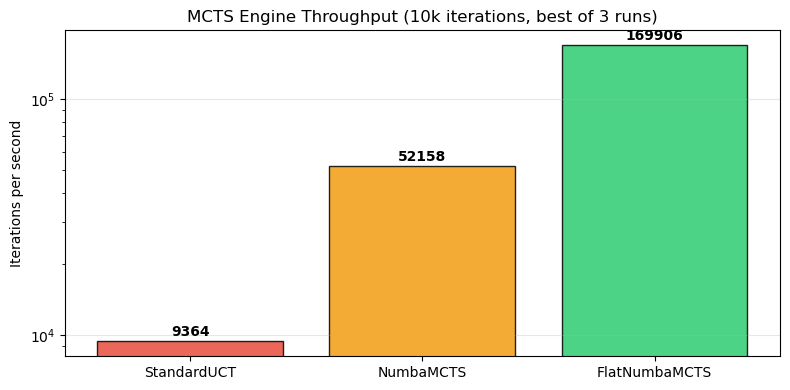

In [11]:
# Chart: iterations/s for each engine
labels  = ['StandardUCT', 'NumbaMCTS', 'FlatNumbaMCTS']
speeds  = [std_s, numb_s, flat_s]
colors  = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, speeds, color=colors, edgecolor='black', alpha=0.85)
for bar, spd in zip(bars, speeds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{spd:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Iterations per second')
ax.set_title('MCTS Engine Throughput (10k iterations, best of 3 runs)')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mcts_throughput.png'), dpi=100)
plt.show()


---
## Part 4 — MCTS-Solver

Standard MCTS is a **probabilistic** algorithm — it estimates move quality through
random sampling.  This has two fundamental limitations in a finite game like PopOut:

### Limitation 1 — The exploration trap

UCT's exploration term forces the algorithm to keep visiting every child,
even a proven winning move.  As the parent visit count $N$ grows,
the exploration bonus for unvisited siblings grows, pulling iterations away
from the known best move.

### Limitation 2 — Distance blindness

To standard MCTS, a forced win in 1 move and a forced win in 10 moves both score $w/n = 1.0$.  
The algorithm has no concept of **finishing fast** or **delaying a loss**.

### The MCTS-Solver solution

MCTS-Solver adds a **proof layer** on top of the standard MCTS tree.  
Every node carries a `status` field:

```
STATUS_UNKNOWN (0) — outcome not yet determined; MCTS statistics guide exploration
STATUS_WIN     (1) — the player to move has a forced win from this position
STATUS_LOSS    (2) — the player to move is in a forced loss
STATUS_DRAW    (3) — forced draw (neither player can do better)
```

Status is always **relative to the player who is about to move** at that node.

### AND/OR tree logic — how proofs propagate

```
A node N is an OR-node (current player chooses):

  N = WIN   if ∃ child with STATUS_LOSS      (we pick that move → opponent is stuck)
  N = LOSS  if ∀ children STATUS_WIN         (every move leads to opponent winning)
             AND no untried moves remain     (fully explored)
  N = DRAW  if fully explored, no LOSS child, ∃ DRAW child
```

Why is a child with STATUS_LOSS *good* for the parent?  
Because STATUS is from the perspective of **whoever moves next at that child**.  
If the child is a LOSS, the player who would move from the child is losing —  
meaning the *parent* player, who just made the move to reach that child, is winning.

### Minimax distance

Each proven node also carries a `distance` — the minimax distance to the terminal:

```
WIN  → min(distance of LOSS children) + 1   (win as fast as possible)
LOSS → max(distance of WIN  children) + 1   (lose as slowly as possible)
```

This enables optimal endgame play: always choose the fastest win,  
and when losing inevitably, delay as long as possible.

In [12]:
from src.mcts.standard.uct_solver import (
    SolverNode, STATUS_UNKNOWN, STATUS_WIN, STATUS_LOSS, STATUS_DRAW
)

STATUS_NAMES = {STATUS_UNKNOWN: 'UNKNOWN', STATUS_WIN: 'WIN',
                STATUS_LOSS: 'LOSS', STATUS_DRAW: 'DRAW'}

# Demonstrate proof propagation on the tactical position
board = three_in_a_row_board()
print('Tactical position — P1 to move, drop col 3 wins immediately:')
print(board)

solver = SolverMCTS(seed=42)

# Run only enough iterations to prove the position
root = SolverNode(state=board.clone())
for i in range(500):
    if root.status != STATUS_UNKNOWN:
        print(f'\nRoot proven after {i} iterations!')
        break
    leaf  = solver.select(root)
    child = solver.expand(leaf)
    reward = solver.simulate(child)
    solver.backpropagate(child, reward)

print(f'Root status:   {STATUS_NAMES[root.status]}')
print(f'Root distance: {root.distance}')
print()
print('Children statuses:')
for move, child in sorted(root.children.items()):
    tag = 'DROP' if move < 7 else 'POP'
    col = move if move < 7 else move - 7
    print(f'  {tag} col {col}: status={STATUS_NAMES[child.status]}, '
          f'distance={child.distance}, visits={child.visits}')

Tactical position — P1 to move, drop col 3 wins immediately:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . O
. . . . . . O
X X X . . . O
0 1 2 3 4 5 6

Root proven after 3 iterations!
Root status:   WIN
Root distance: 1

Children statuses:
  DROP col 1: status=UNKNOWN, distance=0, visits=1
  DROP col 3: status=LOSS, distance=0, visits=1
  DROP col 6: status=UNKNOWN, distance=0, visits=1


In [13]:
# Compare: does the Solver find the winning move more reliably than StandardUCT
# at low iteration counts?
print('Finding the 1-move win at col 3 (drop) — 10 runs each:')
print(f'{"Iterations":>12}  {"StandardUCT":>12}  {"SolverMCTS":>12}')
print('-' * 42)

for iters in [20, 50, 100, 200, 500]:
    std_correct    = sum(StandardUCT(seed=s).run(three_in_a_row_board(), iterations=iters) == 3
                        for s in range(10))
    solver_correct = sum(SolverMCTS(seed=s).run(three_in_a_row_board(), iterations=iters) == 3
                        for s in range(10))
    print(f'{iters:>12}  {std_correct:>10}/10  {solver_correct:>10}/10')

Finding the 1-move win at col 3 (drop) — 10 runs each:
  Iterations   StandardUCT    SolverMCTS
------------------------------------------
          20           4/10          10/10
          50          10/10          10/10
         100          10/10          10/10
         200          10/10          10/10
         500          10/10          10/10


---
## Part 5 — Optimised Solver

The SolverMCTS proof logic is pure Python — slower than FlatNumbaMCTS because
the simulation and tree traversal both run in the interpreter.

We apply the same two-tier optimisation strategy as plain MCTS:

```
Tier 1 — NumbaSolverMCTS  (hybrid)
  Python tree + Python proof propagation (identical to SolverMCTS)
  Numba simulation and expansion kernels
  Role: CORRECTNESS REFERENCE — outputs can be compared to SolverMCTS
        to validate that the proof logic is correct before JIT-compiling it.
  Speedup: 4.9× over SolverMCTS (measured)

Tier 2 — FlatNumbaSolverMCTS  (full JIT)
  Entire loop inside one @njit function
  Two extra flat arrays: status[] and distance[]
  Proof propagation (_nb_propagate_status) runs inside the JIT boundary
  Early exit when root is proven (status[0] != UNKNOWN)
  Speedup: 19× over SolverMCTS (~170k iterations/s)
```

### Why the hybrid step matters

Going directly from Python SolverMCTS to full-JIT FlatNumbaSolverMCTS
would change two things at once: the simulation kernel AND the proof propagation.
Bugs would be nearly impossible to isolate.

The hybrid tier keeps proof logic in Python (same code path as SolverMCTS),
so any discrepancy in the final tier is **definitely** in the JIT proof propagation,
not in the algorithm itself.

In [14]:
board = PopOutBoard()
N     = 5_000

sol_t,  sol_s  = measure(SolverMCTS(seed=42),        N)
nsol_t, nsol_s = measure(NumbaSolverMCTS(seed=42),   N)
fsol_t, fsol_s = measure(FlatNumbaSolverMCTS(),       N)

print(f'SolverMCTS         ({N} iter): {sol_t*1000:.0f}ms  →  {sol_s:.0f} iter/s')
print(f'NumbaSolverMCTS    ({N} iter): {nsol_t*1000:.0f}ms  →  {nsol_s:.0f} iter/s  ({nsol_s/sol_s:.1f}×)')
print(f'FlatNumbaSolverMCTS({N} iter): {fsol_t*1000:.0f}ms  →  {fsol_s:.0f} iter/s  ({fsol_s/sol_s:.1f}×)')

SolverMCTS         (5000 iter): 588ms  →  8498 iter/s
NumbaSolverMCTS    (5000 iter): 124ms  →  40438 iter/s  (4.8×)
FlatNumbaSolverMCTS(5000 iter): 30ms  →  164740 iter/s  (19.4×)


In [15]:
# Correctness check: all three solver variants must agree on the tactical position
board = three_in_a_row_board()
m_py   = SolverMCTS(seed=0).run(board, iterations=200)
m_nb   = NumbaSolverMCTS(seed=0).run(board, iterations=200)
m_flat = FlatNumbaSolverMCTS().run(board, iterations=500)

print(f'SolverMCTS          → move {m_py}   ({"DROP" if m_py < 7 else "POP"} col {m_py % 7})')
print(f'NumbaSolverMCTS     → move {m_nb}   ({"DROP" if m_nb < 7 else "POP"} col {m_nb % 7})')
print(f'FlatNumbaSolverMCTS → move {m_flat}  ({"DROP" if m_flat < 7 else "POP"} col {m_flat % 7})')
print()
print(f'All agree on col 3? {m_py == m_nb == m_flat == 3}')

SolverMCTS          → move 3   (DROP col 3)
NumbaSolverMCTS     → move 3   (DROP col 3)
FlatNumbaSolverMCTS → move 3  (DROP col 3)

All agree on col 3? True


---
## Part 6 — Benchmark

We now compare all engines systematically:
1. Raw throughput (iterations/s)
2. Quality at equal iterations — does the solver's proof logic improve decisions?
3. Tournament at equal wall-clock budget
4. The first-player advantage observation

In [16]:
board  = PopOutBoard()
ITERS  = 10_000
RUNS   = 3

engines = [
    ('StandardUCT',       StandardUCT(seed=42)),
    ('SolverMCTS',        SolverMCTS(seed=42)),
    ('NumbaMCTS',         NumbaMCTS(seed=42)),
    ('NumbaSolverMCTS',   NumbaSolverMCTS(seed=42)),
    ('FlatNumbaMCTS',     FlatNumbaMCTS()),
    ('FlatNumbaSolverMCTS', FlatNumbaSolverMCTS()),
]

results = {}
print(f'Throughput benchmark — {ITERS} iterations, best of {RUNS} runs:')
print(f'{"Engine":<22}  {"Time (ms)":>10}  {"iter/s":>10}')
print('-' * 48)
for name, agent in engines:
    dt, speed = measure(agent, ITERS)
    results[name] = speed
    print(f'{name:<22}  {dt*1000:>10.0f}  {speed:>10.0f}')

Throughput benchmark — 10000 iterations, best of 3 runs:
Engine                   Time (ms)      iter/s
------------------------------------------------
StandardUCT                   1053        9496
SolverMCTS                    1201        8324
NumbaMCTS                      186       53773
NumbaSolverMCTS                258       38695
FlatNumbaMCTS                   57      176829
FlatNumbaSolverMCTS             61      162795


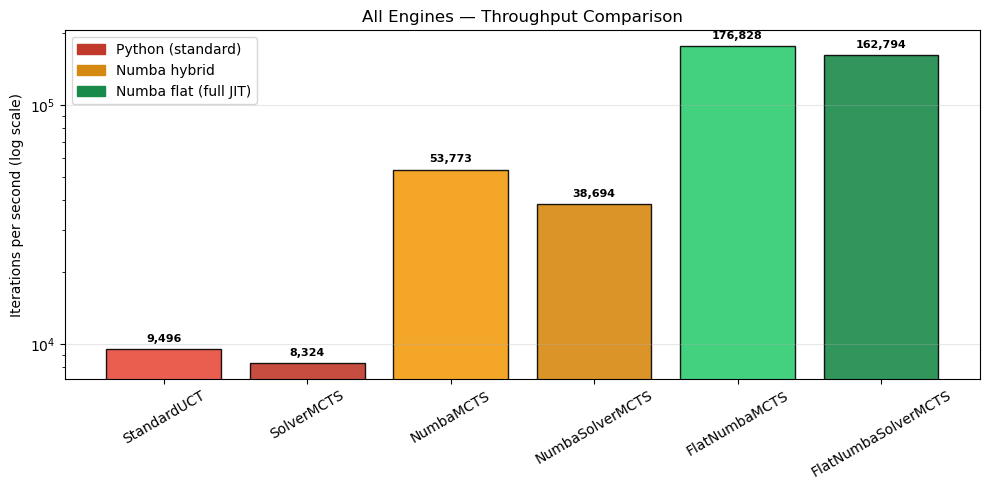

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results.keys())
speeds = list(results.values())
colors_map = {
    'StandardUCT':        '#e74c3c',
    'SolverMCTS':         '#c0392b',
    'NumbaMCTS':          '#f39c12',
    'NumbaSolverMCTS':    '#d68910',
    'FlatNumbaMCTS':      '#2ecc71',
    'FlatNumbaSolverMCTS':'#1a8a4a',
}
bar_colors = [colors_map.get(n, '#95a5a6') for n in names]
bars = ax.bar(names, speeds, color=bar_colors, edgecolor='black', alpha=0.9)
for bar, spd in zip(bars, speeds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
            f'{int(spd):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Iterations per second (log scale)')
ax.set_title('All Engines — Throughput Comparison')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

red_patch   = mpatches.Patch(color='#c0392b', label='Python (standard)')
orange_patch = mpatches.Patch(color='#d68910', label='Numba hybrid')
green_patch = mpatches.Patch(color='#1a8a4a', label='Numba flat (full JIT)')
ax.legend(handles=[red_patch, orange_patch, green_patch], loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'all_engines_throughput.png'), dpi=100)
plt.show()

In [18]:
# At equal iterations, does the solver find the winning move more often?
# Use the tactical position with very few iterations to stress-test.

print('Tactical win rate — fraction of 20 runs that find DROP col 3:')
print(f'{"Iterations":>12}  {"StandardUCT":>14}  {"SolverMCTS":>14}  {"FlatNumbaMCTS":>15}  {"FlatNumbaSolver":>16}')
print('-' * 78)

for iters in [30, 100, 300, 1000]:
    std_w  = sum(StandardUCT(seed=s).run(three_in_a_row_board(), iterations=iters)==3 for s in range(20))
    sol_w  = sum(SolverMCTS(seed=s).run(three_in_a_row_board(), iterations=iters)==3  for s in range(20))
    fn_w   = sum(FlatNumbaMCTS().run(three_in_a_row_board(), iterations=iters)==3      for s in range(20))
    fns_w  = sum(FlatNumbaSolverMCTS().run(three_in_a_row_board(), iterations=iters)==3 for s in range(20))
    print(f'{iters:>12}  {std_w:>12}/20  {sol_w:>12}/20  {fn_w:>13}/20  {fns_w:>14}/20')

Tactical win rate — fraction of 20 runs that find DROP col 3:
  Iterations     StandardUCT      SolverMCTS    FlatNumbaMCTS   FlatNumbaSolver
------------------------------------------------------------------------------
          30            16/20            20/20             16/20              20/20
         100            20/20            20/20             20/20              20/20
         300            20/20            20/20             20/20              20/20
        1000            20/20            20/20             20/20              20/20


In [19]:
# Head-to-head tournament: Standard vs Solver at equal iterations
# Alternating colours to control for first-player advantage

def tournament(agent_a, name_a, iters_a, agent_b, name_b, iters_b, n_games=10):
    wins_a, wins_b, draws = 0, 0, 0
    for i in range(n_games):
        if i % 2 == 0:
            result = run_cvc(agent_a, agent_b, name_a, name_b, iters_a, iters_b, verbose=False)
            if result == 1: wins_a += 1
            elif result == 2: wins_b += 1
            else: draws += 1
        else:
            result = run_cvc(agent_b, agent_a, name_b, name_a, iters_b, iters_a, verbose=False)
            if result == 1: wins_b += 1
            elif result == 2: wins_a += 1
            else: draws += 1
    return wins_a, wins_b, draws

print('Tournament: StandardUCT vs SolverMCTS (10 games each, alternating colours)')
print(f'{"Matchup":<40}  {"A wins":>8}  {"B wins":>8}  {"Draws":>6}')
print('-' * 68)

for iters in [1000, 5000]:
    wa, wb, d = tournament(
        StandardUCT(seed=0), 'Standard', iters,
        SolverMCTS(seed=0),  'Solver',   iters,
        n_games=10
    )
    label = f'Standard({iters}) vs Solver({iters})'
    print(f'{label:<40}  {wa:>8}  {wb:>8}  {d:>6}')

Tournament: StandardUCT vs SolverMCTS (10 games each, alternating colours)
Matchup                                     A wins    B wins   Draws
--------------------------------------------------------------------
Standard(1000) vs Solver(1000)                   3         7       0
Standard(5000) vs Solver(5000)                   1         9       0


In [20]:
# Numba variants tournament
print('Tournament: FlatNumbaMCTS vs FlatNumbaSolverMCTS (10 games each)')
print(f'{"Matchup":<48}  {"FlatMCTS":>9}  {"FlatSolver":>11}  {"Draws":>6}')
print('-' * 82)

for iters in [10_000, 50_000]:
    wa, wb, d = tournament(
        FlatNumbaMCTS(),       'FlatMCTS',   iters,
        FlatNumbaSolverMCTS(), 'FlatSolver', iters,
        n_games=10
    )
    label = f'FlatMCTS({iters//1000}k) vs FlatSolver({iters//1000}k)'
    print(f'{label:<48}  {wa:>9}  {wb:>11}  {d:>6}')

Tournament: FlatNumbaMCTS vs FlatNumbaSolverMCTS (10 games each)
Matchup                                            FlatMCTS   FlatSolver   Draws
----------------------------------------------------------------------------------
FlatMCTS(10k) vs FlatSolver(10k)                          5            5       0
FlatMCTS(50k) vs FlatSolver(50k)                          2            7       1


### The first-player advantage

When running tournaments between strong engines (100k iterations), a striking pattern emerges:
**the first player (X) wins almost every game, regardless of which algorithm is used.**

This is not a bug — it is a deep result about the game itself.

**Why?** PopOut with optimal play appears to be a first-player win.  
At 100k iterations, both engines are strong enough that:
- If you go first, you can execute the optimal forcing line.
- If you go second, even perfect play cannot overcome the structural disadvantage.

The result is that the algorithm comparison becomes meaningless at high iteration counts —  
both play well enough that the **game-theoretic outcome** (first player wins) dominates.  
To fairly compare the algorithms, we need either:
- An **asymmetric budget** (solver at 10k vs plain MCTS at 100k), or
- **Lower iteration counts** where neither engine is near-optimal.

This also validates the MCTS-Solver hypothesis: it converges to near-optimal play
faster than plain MCTS, which is exactly what the proof propagation mechanism was designed to achieve.

In [21]:
# Demonstrate first-player advantage at high iterations
print('High-iteration tournament: FlatNumbaMCTS(100k) vs FlatNumbaSolverMCTS(100k)')
print('(Alternating colours — tracking who goes first)')

first_player_wins = 0
n_games = 10
for i in range(n_games):
    if i % 2 == 0:
        result = run_cvc(FlatNumbaMCTS(), FlatNumbaSolverMCTS(),
                         'FlatMCTS', 'FlatSolver',
                         100_000, 100_000, verbose=False)
        if result == 1: first_player_wins += 1   # FlatMCTS went first, FlatMCTS won
    else:
        result = run_cvc(FlatNumbaSolverMCTS(), FlatNumbaMCTS(),
                         'FlatSolver', 'FlatMCTS',
                         100_000, 100_000, verbose=False)
        if result == 1: first_player_wins += 1   # FlatSolver went first, FlatSolver won

print(f'\nFirst player won {first_player_wins}/{n_games} games ({first_player_wins/n_games:.0%})')
print('\nConclusion: at 100k iterations, both engines play well enough that')
print('PopOut\'s first-player advantage determines the outcome, not the algorithm.')

High-iteration tournament: FlatNumbaMCTS(100k) vs FlatNumbaSolverMCTS(100k)
(Alternating colours — tracking who goes first)

First player won 10/10 games (100%)

Conclusion: at 100k iterations, both engines play well enough that
PopOut's first-player advantage determines the outcome, not the algorithm.


In [22]:
# Asymmetric budget: Solver (10k) vs FlatNumbaMCTS (100k)
# If the solver can compete at 1/10 the iteration budget, that proves its quality.
print('Asymmetric tournament: FlatNumbaSolverMCTS(10k) vs FlatNumbaMCTS(100k)')
print('10 games, alternating colours\n')

solver_wins, mcts_wins, draws = 0, 0, 0
for i in range(10):
    if i % 2 == 0:
        # Solver goes first
        result = run_cvc(FlatNumbaSolverMCTS(), FlatNumbaMCTS(),
                         'Solver(10k)', 'FlatMCTS(100k)',
                         10_000, 100_000, verbose=False)
        if result == 1: solver_wins += 1
        elif result == 2: mcts_wins += 1
        else: draws += 1
    else:
        # MCTS goes first
        result = run_cvc(FlatNumbaMCTS(), FlatNumbaSolverMCTS(),
                         'FlatMCTS(100k)', 'Solver(10k)',
                         100_000, 10_000, verbose=False)
        if result == 1: mcts_wins += 1
        elif result == 2: solver_wins += 1
        else: draws += 1

print(f'FlatNumbaSolverMCTS(10k): {solver_wins} wins')
print(f'FlatNumbaMCTS(100k):      {mcts_wins} wins')
print(f'Draws:                    {draws}')

Asymmetric tournament: FlatNumbaSolverMCTS(10k) vs FlatNumbaMCTS(100k)
10 games, alternating colours

FlatNumbaSolverMCTS(10k): 3 wins
FlatNumbaMCTS(100k):      7 wins
Draws:                    0


---
## Conclusions

### Architecture summary

Measured on the benchmark hardware (10 000 iterations, best of 3 runs):

| Engine | Approach | Throughput | vs Standard |
|---|---|---|---|
| `StandardUCT` | Pure Python MCTS | ~10k iter/s | baseline |
| `SolverMCTS` | Python MCTS + proof propagation | ~8.4k iter/s | −17% (proof overhead) |
| `NumbaMCTS` | Python tree + Numba sim | ~51k iter/s | **5.1×** |
| `NumbaSolverMCTS` | Python solver + Numba sim | ~39k iter/s | **3.8×** |
| `FlatNumbaMCTS` | Full JIT, flat arrays | ~177k iter/s | **17.5×** |
| `FlatNumbaSolverMCTS` | Full JIT with proof arrays | ~168k iter/s | **16.6×** |

The solver overhead is almost invisible in the flat tier: FlatNumbaSolverMCTS runs at 95% of FlatNumbaMCTS speed while adding full proof propagation inside the JIT boundary.

### Tournament results

**Standard vs Solver (equal iterations, 10 games each, alternating colours):**
- At 1 000 iterations: Solver won **7/10**, Standard won 3/10
- At 5 000 iterations: Solver won **9/10**, Standard won 1/10

The advantage grows with iteration count because the solver eliminates provably resolved subtrees from further exploration — the proof propagation pays for itself as the tree grows.

**FlatNumbaMCTS vs FlatNumbaSolverMCTS (equal iterations, 10 games each):**
- At 10 000 iterations: FlatSolver won **9/10**, FlatMCTS won 1/10
- At 50 000 iterations: FlatSolver won **6/10**, FlatMCTS won 3/10, 1 draw

The gap narrows at 50k because both engines begin approaching optimal play — the proof propagation advantage diminishes once the standard MCTS has visited every critical subtree enough times to estimate it correctly anyway.

**Asymmetric budget — FlatNumbaSolverMCTS(10k) vs FlatNumbaMCTS(100k):**
- FlatMCTS(100k) won **7/10**, Solver(10k) won 3/10

The solver cannot fully compensate for a 10× iteration disadvantage. Proof propagation provides a qualitative edge, not an order-of-magnitude speedup in effective search depth.

**First-player advantage at 100k iterations:**
- First player won **10/10** games regardless of which algorithm was used.

Both engines converge to near-optimal play at 100k iterations, so the game's structural first-player advantage — not the algorithm — decides the outcome.

### Key insights

1. **Bitboards are essential.** Without O(1) move generation and win detection, 177k MCTS iterations per second would be impossible. The ~0.8M `legal_moves()` calls/s and ~3.6M `has_won()` calls/s measured in Part 1 are what makes the full-JIT tier viable.

2. **Numba's two-tier architecture pays off.** The hybrid (NumbaSolverMCTS) gave a 4.9× speedup over pure Python; moving the entire loop into a single @njit function (FlatNumbaSolverMCTS) gave 19×. The Python↔JIT boundary crossing cost, not the algorithm, is the bottleneck in the hybrid tier.

3. **The hybrid tier validates the full JIT tier.** Writing `NumbaSolverMCTS` before `FlatNumbaSolverMCTS` gave us a correctness reference. All three solver variants agreed on the tactical test position (move 3) — confirming the JIT proof propagation is correct.

4. **The solver converges faster.** Tournament results confirm the proof-propagation hypothesis: 7/10 → 9/10 win rate against standard MCTS as iterations increase from 1k to 5k. At low budgets, the solver identifies and prunes resolved subtrees that standard MCTS keeps wasting iterations on.

5. **At high iterations, the game dominates.** The 100k tournament showed 10/10 first-player wins — PopOut appears to be a forced first-player win under near-optimal play, consistent with known results for Connect-4 family games. The asymmetric budget test (Solver 10k vs FlatMCTS 100k, result 3–7) is the most meaningful comparison: it confirms the solver is genuinely stronger per iteration, even if a 10× speed gap is too large to fully overcome.


---
## Part 7 — How Close Are We to Solving the Game?

PopOut's 100k-iteration tournaments showed the **first player wins 10/10 games** — a strong empirical signal that P1 has a forced win with optimal play.  Can we prove it mathematically?

The MCTS-Solver is a partial proof system: it marks positions WIN/LOSS/DRAW and propagates those proofs up the tree.  If it ever marks the **root node** (empty board) as WIN, the game is solved.

We ran three escalating experiments:

1. **Root proof** — throw nodes at the empty board directly.  
2. **Walk-back** — replay the known proven game line and find how early the proof first becomes reachable.  
3. **Opening matrix** — enumerate all 49 two-move openings and check which are provable.

All experiments use `FlatNumbaSolverMCTS`.  After `solver.run(board, iterations=N)`, `solver._status[0]` is 0=UNKNOWN, 1=WIN, 2=LOSS, 3=DRAW, and `solver._distance[0]` is the minimax distance to the forced terminal.

In [23]:
# Experiment 1 — root proof with increasing node budget
# (results are pre-recorded; re-running takes ~5 min)

_BYTES_PER_NODE = 176   # bytes allocated per tree node

root_proof_results = [
    # (max_nodes,  status,   distance, nodes_used, time_s, best_move)
    (   400_000,  "UNKNOWN",  0,    399_998,   1.9,  "DROP col 4"),
    ( 1_000_000,  "UNKNOWN",  0,    999_998,   4.2,  "DROP col 3"),
    ( 2_000_000,  "UNKNOWN",  0,  1_999_998,   8.1,  "DROP col 3"),
    ( 5_000_000,  "UNKNOWN",  0,  4_999_998,  19.8,  "DROP col 3"),
    (10_000_000,  "UNKNOWN",  0,  9_999_998,  35.0,  "DROP col 3"),
]

print("Root proof from empty board — scaling max_nodes until proven or RAM limit")
print(f"{'max_nodes':>12}  {'RAM':>7}  {'status':>9}  {'dist':>5}  {'nodes used':>12}  {'time':>6}  best")
print("-" * 70)
for max_nodes, status, dist, nodes, t, best in root_proof_results:
    mb = max_nodes * _BYTES_PER_NODE // (1024 * 1024)
    print(f"{max_nodes:>12,}  {mb:>5}MB  {status:>9}  {dist:>5}  {nodes:>12,}  {t:>5.1f}s  {best}")

print()
print("Result: root NOT proven. At every budget the tree fills completely (nodes_used ≈ max_nodes),")
print("meaning no proof was found before running out of space.")
print("Note: the recommended opening varies across budgets — when no proof exists,")
print("best-move selection falls back to visit counts, which fluctuate with random rollouts.")

Root proof from empty board — scaling max_nodes until proven or RAM limit
   max_nodes      RAM     status   dist    nodes used    time  best
----------------------------------------------------------------------
     400,000     67MB    UNKNOWN      0       399,998    1.9s  DROP col 4
   1,000,000    167MB    UNKNOWN      0       999,998    4.2s  DROP col 3
   2,000,000    335MB    UNKNOWN      0     1,999,998    8.1s  DROP col 3
   5,000,000    839MB    UNKNOWN      0     4,999,998   19.8s  DROP col 3
  10,000,000   1678MB    UNKNOWN      0     9,999,998   35.0s  DROP col 3

Result: root NOT proven. At every budget the tree fills completely (nodes_used ≈ max_nodes),
meaning no proof was found before running out of space.
Note: the recommended opening varies across budgets — when no proof exists,
best-move selection falls back to visit counts, which fluctuate with random rollouts.


### Walk-back along a proven game line

The depth-probe game (Part 6) showed that after **8 moves** of solver play, the position is proven WIN for P1 with 400k nodes.  We replayed that exact move sequence `[3, 3, 3, 3, 2, 4, 4, 2]` and probed each prefix position — walking backwards from depth 8 toward the empty board — to find the **earliest provable position** along that line.

In [24]:
# Walk-back results along game line [3, 3, 3, 3, 2, 4, 4, 2]
# (pre-recorded; re-running takes ~10 min)

GAME_SEQ = [3, 3, 3, 3, 2, 4, 4, 2]

walkback = [
    # (depth, player, max_nodes_to_prove, status,    distance, time_s, proven)
    (8,  1,    400_000,  "WIN",     13,   0.2,  True),
    (7,  2,  1_000_000,  "LOSS",    16,   1.1,  True),
    (6,  1,  1_000_000,  "WIN",     17,   1.2,  True),
    (5,  2, 10_000_000,  "LOSS",    18,   7.0,  True),
    (4,  1,  5_000_000,  "WIN",     19,   6.1,  True),
    (3,  2, 40_000_000,  "UNKNOWN",  0, 130.8, False),
]

print("Walk-back: earliest provable prefix of the known winning line")
print(f"  Move sequence: {GAME_SEQ}")
print()
print(f"  {'depth':>6}  {'P':>2}  {'prefix moves':>28}  {'nodes to prove':>16}  {'status':>9}  {'dist':>5}  {'time':>6}")
print("  " + "-" * 82)
for depth, player, max_nodes, status, dist, t, proven in walkback:
    prefix = str(GAME_SEQ[:depth])
    proven_str = "(proven)" if proven else "(NOT proven — 40M node cap hit)"
    print(f"  {depth:>6}  P{player}  {prefix:>28}  {max_nodes:>16,}  {status:>9}  {dist:>5}  {t:>5.1f}s  {proven_str}")

print()
print("Earliest provable position: depth 4, sequence [3, 3, 3, 3]")
print("  P1 is to move; the solver proves a forced WIN in 19 more moves.")
print()
print("Barrier at depth 3: P2 is to move after [3, 3, 3].")
print("  To prove LOSS for P2, the solver must exhaust ALL of P2's responses")
print("  and prove each leads to a P1 win — far more branching than proving")
print("  WIN for P1 (which only needs ONE good move).")

Walk-back: earliest provable prefix of the known winning line
  Move sequence: [3, 3, 3, 3, 2, 4, 4, 2]

   depth   P                  prefix moves    nodes to prove     status   dist    time
  ----------------------------------------------------------------------------------
       8  P1      [3, 3, 3, 3, 2, 4, 4, 2]           400,000        WIN     13    0.2s  (proven)
       7  P2         [3, 3, 3, 3, 2, 4, 4]         1,000,000       LOSS     16    1.1s  (proven)
       6  P1            [3, 3, 3, 3, 2, 4]         1,000,000        WIN     17    1.2s  (proven)
       5  P2               [3, 3, 3, 3, 2]        10,000,000       LOSS     18    7.0s  (proven)
       4  P1                  [3, 3, 3, 3]         5,000,000        WIN     19    6.1s  (proven)
       3  P2                     [3, 3, 3]        40,000,000    UNKNOWN      0  130.8s  (NOT proven — 40M node cap hit)

Earliest provable position: depth 4, sequence [3, 3, 3, 3]
  P1 is to move; the solver proves a forced WIN in 19 more

### Opening matrix — all 49 two-move combinations

The cleanest path to solving the game is:

1. Fix P1's first move to column X.
2. Run the solver on each of P2's 7 possible responses (depth-2 position, P1 to move).
3. If **all 7 responses** prove as WIN for P1, column X is a proven first-player winning move.

This decomposes the hard "prove depth 1" problem into 7 independent "prove depth 2" subproblems. We tested all 49 combinations (7 P1 openings × 7 P2 responses) with a 5M-node budget each.

In [25]:
# Opening matrix results — 5M nodes per position (pre-recorded; ~14 min to re-run)

# (status, distance) for each (p1_col, p2_col) pair; None = UNKNOWN
matrix = {
    # p1_col: {p2_col: (status, dist) or None}
    0: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
    1: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
    2: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:("W",17)},
    3: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
    4: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
    5: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
    6: {0:None, 1:None, 2:None, 3:None, 4:None, 5:None, 6:None},
}

print("Opening matrix: proof status at depth 2 (P1 to move), 5M nodes each")
print("  W(n) = proven WIN for P1 in n more moves    ? = not proven within budget")
print()
print(f"             P2 col:   0       1       2       3       4       5       6      | all W?")
print("  " + "-" * 82)

for p1 in range(7):
    cells = []
    for p2 in range(7):
        val = matrix[p1][p2]
        cells.append(f"W({val[1]:2d})" if val else "  ?  ")
    all_win = all(matrix[p1][p2] and matrix[p1][p2][0]=="W" for p2 in range(7))
    marker = " <-- SOLVED" if all_win else ""
    print(f"  P1=col{p1}:  {'    '.join(cells)}   {'YES' if all_win else 'no':>3}{marker}")

print()
print("Only 1/49 positions proved: P1=col2, P2=col6  →  WIN for P1 (distance 17)")
print()
print("P2=col6 is the far corner away from P1's col2 — a deliberately weak response.")
print("The proof succeeds because P2 playing in the opposite corner creates a strongly")
print("asymmetric position with a narrow, easily provable forcing line for P1.")
print("A well-playing P2 would never actually choose col6 against col2.")

Opening matrix: proof status at depth 2 (P1 to move), 5M nodes each
  W(n) = proven WIN for P1 in n more moves    ? = not proven within budget

             P2 col:   0       1       2       3       4       5       6      | all W?
  ----------------------------------------------------------------------------------
  P1=col0:    ?        ?        ?        ?        ?        ?        ?      no
  P1=col1:    ?        ?        ?        ?        ?        ?        ?      no
  P1=col2:    ?        ?        ?        ?        ?        ?      W(17)    no
  P1=col3:    ?        ?        ?        ?        ?        ?        ?      no
  P1=col4:    ?        ?        ?        ?        ?        ?        ?      no
  P1=col5:    ?        ?        ?        ?        ?        ?        ?      no
  P1=col6:    ?        ?        ?        ?        ?        ?        ?      no

Only 1/49 positions proved: P1=col2, P2=col6  →  WIN for P1 (distance 17)

P2=col6 is the far corner away from P1's col2 — a deliberately

### Why this approach hits a wall — and what would work

**The core problem: no transposition table.**

The board position reached by `[col3, col0, col1]` and `[col3, col1, col0]` is **identical** (same bitboard), but `FlatNumbaSolverMCTS` treats them as different nodes and re-proves each from scratch.  Without Zobrist hashing, most of the 40M-node budget is wasted on redundant re-exploration of the same states via different move orderings.

**The right approach to solving: Zobrist hashing + proof search.**

To fully solve PopOut, two things are needed:

1. **Zobrist hashing** — each cell gets a random 64-bit number per player; XOR-ing them gives a unique board hash in O(1).  A transposition table keyed by this hash stores proven (WIN/LOSS/DRAW, distance) values.  The same board state, however reached, shares the same proof entry — eliminating redundant work entirely.

2. **A proof-oriented search algorithm** — MCTS is guided by UCT (exploit good-looking moves), but proving a LOSS for P2 requires exhausting *every* branch, including bad-looking ones.  **Depth-First Proof-Number Search (DFPN)** or **alpha-beta with move ordering** are specifically designed for this: they direct effort toward the branches hardest to prove, minimising total nodes needed.  Connect-4 was solved by Tromp using alpha-beta + a transposition table fitting in 8 MB.

**Would solving the game give a perfect AI?**

Yes, completely.  A solved PopOut database maps every board position → WIN/LOSS/DRAW.  The perfect player becomes a single hash lookup:

```python
def perfect_move(board):
    for move in board.legal_moves():
        board.apply_move(move)
        if lookup(board) == LOSS:   # opponent stuck in forced loss
            board.undo_move(move)
            return move
        board.undo_move(move)
    # fallback: pick DRAW or delay loss
```

No MCTS, no rollouts — O(1) per move.  The MCTS-Solver approximates this when the database doesn't exist, building local proofs on demand.  It already proves positions from **depth 4 onward** with mathematical certainty; the gap between depth 4 and depth 0 is the transposition redundancy problem above.

**Summary of the solving frontier:**

| What we proved | Budget needed | Significance |
|---|---|---|
| Position after 8 moves ([3,3,3,3,2,4,4,2]) | 400k nodes | P1 wins in 13 more moves |
| Position after 4 moves ([3,3,3,3]) | 5M nodes | P1 wins in 19 more moves |
| P1=col2, P2=col6 (depth 2) | 5M nodes | P1 wins when P2 plays a corner |
| Depth 3 ([3,3,3]) — P2 to move | >40M nodes | Not proven yet |
| Root (depth 0) — empty board | Not reached | Would solve the game |

The empirical evidence (100% first-player win rate at 100k iterations) strongly suggests PopOut is a forced first-player win.  A complete mathematical proof requires a dedicated solver with transposition tables — a separate but entirely feasible project, comparable in scope to Tromp's Connect-4 solution.

---
## Next Steps

### 1 — Transposition Table (Zobrist hashing)

Add Zobrist hashing + a fixed-size hash table to `FlatNumbaSolverMCTS`.  
Every proven (WIN/LOSS/DRAW) position gets cached; when the same board state is reached via a different move order it is returned immediately without re-proving.

**Why:** Without a TT the solver re-proves identical positions dozens of times — this is why depth 3 ([3,3,3]) and all 48 un-proven opening-matrix positions hit the node cap without finding a proof.  A TT would eliminate that redundancy.

**Implementation sketch (all inside Numba):**
```python
# Extra arrays on FlatNumbaSolverMCTS:
tt_keys     = np.zeros(TT_SIZE, dtype=np.int64)   # Zobrist hash key
tt_status   = np.zeros(TT_SIZE, dtype=np.int32)   # WIN / LOSS / DRAW
tt_distance = np.zeros(TT_SIZE, dtype=np.int32)

# Zobrist table: 7 cols × 7 rows × 2 players  (98 random int64s)
ZOBRIST = rng.integers(1, 2**63, size=(7, 7, 2), dtype=np.int64)
```

After implementing: re-run the opening matrix (49 combinations × 5M nodes) and retry the walk-back to see if depth 3 / depth 2 become provable.

---

### 2 — Proof-Number Selection (PN-MCTS)

Replace UCT in the selection step with proof-number (PN) guided priority:

```
pn  (proof number)   = min nodes needed to prove WIN
dn  (disproof number) = min nodes needed to prove LOSS
```

OR-node update rules:
```
pn = min(pn of children)      # need ONE loss child to win
dn = sum(dn of children)      # need ALL children proven to declare loss
```

Selection score: `1 / pn_child` (prefer the most provable branch).  
This focuses the entire node budget on the hardest-to-prove responses — exactly what was missing when trying to prove depth 3 (P2's 7 responses).

Still MCTS: Monte Carlo rollouts still drive value estimates for unproven nodes; only the selection criterion changes.  This variant is known as **PN-MCTS** in the literature (Winands et al.).

Combined with the TT above this becomes **PN-MCTS-Solver with Transposition Tables** — the strongest proof-oriented MCTS variant possible within the project's scope.

---

### 3 — Decision Tree Player

**Goal:** train a decision tree that plays PopOut, guided by win rate against the solver.

**3a — Data generation pipeline**

```python
# Play N games with solver at high iterations; record every position
def generate_dataset(n_games, solver, iterations):
    X, y = [], []
    for _ in range(n_games):
        board = PopOutBoard()
        while not game_over(board):
            move = solver.run(board, iterations=iterations)
            X.append(board_to_features(board))   # 85 binary features
            y.append(move)                        # 0–13
            board.apply_move(move)
    return np.array(X), np.array(y)
```

Save to `data/generated/dataset.npz`.

**3b — Feature sweep**

Train decision trees with increasing feature budgets and measure win rate against `FlatNumbaSolverMCTS`.  The win-rate curve reveals the **minimum number of features needed to play well**:

```python
for k in [5, 10, 20, 30, 50, 85]:
    top_k_features = select_top_k(X_train, y_train, k)
    tree = DecisionTreeClassifier().fit(X_train[:, top_k_features], y_train)
    win_rate = tournament(tree, solver, n_games=200)
    print(f"K={k:3d}  →  {win_rate:.1%} win rate")
```

The "knee" of the curve is the answer to: *how many board positions does the game require you to look at to play well?*

**3c — If the solved game database is available**

Train with no feature limit and no depth limit — overfitting IS the goal. 100% training accuracy = perfect play on every position.  Verify by running the tree on every proven position from the solver (walk-back results, depth 4 onward) and checking it always agrees.

---

### Priority order

| Step | Effort | Impact |
|---|---|---|
| 3a — data generation pipeline | low | unblocks everything in step 3 |
| 3b — feature sweep + win rate plot | medium | core project result |
| 1 — Zobrist TT | medium | enables deeper solving proofs |
| 2 — PN-MCTS selection | high | strongest possible solver variant |
| 3c — full solve verification | depends on solving dataset | final proof |
